# Histograms of plume depths

In [16]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statistics
import glob

plt.rc("figure", figsize=(8, 6))
plt.rc("figure", dpi=100)

## Reading a single file

In [17]:
#PATTERN= "/Users/ibaraffe/music_plotdir/krad_mesa_20msundir/zero_avtijt1.52d8-8.45d8_307x313_krad_20msun_r0.12-0.27_t45-135_msy0.55_evY_t1.52d8-8.4d8_newlscaledir/zero.cont*"
PATTERN= "/Users/ibaraffe/music_plotdir/krad_mesa_20msundir/zero_avtij_t1.52d8-1.87d8_307x313x43_20msun_r0.12-0.27_t45-135phi22_msy0.55_evYdir/zero.cont*"
PATTERN= "zero_testdir/zero.cont*"
all_files = sorted(glob.glob(PATTERN))

In [18]:
# Select a subset of files
subset_files = all_files[::1]
#subset_files = all_files[0::10]
print("Will process {} files out of {}".format(len(subset_files), len(all_files)))
print("First file is:", subset_files[0])
print("Last file is:", subset_files[-1])
ncount=len(all_files)
print("ncount= ",ncount)

Will process 466 files out of 466
First file is: zero_testdir/zero.cont99700000001
Last file is: zero_testdir/zero.cont99900000156
ncount=  466


In [19]:
def read_file(fname):
    with open(fname, 'r') as f:
        t = float(f.readline())
        df = pd.read_csv(f, delim_whitespace=True,
                    #names=["num_theta", "theta_deg", "HP1", "r1", "renv", "HP2", "r21", "rcore"])
        #names=["num_theta", "theta_deg", "HP1", "r1", "renv", "HP2", "r21", "rcore", "renvdown", "renvup", "rcoredown", "rcoreup"])
        names=["num_phi", "phi_deg", "num_theta", "theta_deg", "HP1", "r1", "r2","r3","r4","r5", "HP2", "r21", "r22","r23","r24","r25"])
        df["time"] = t
        return df
# r21=zerok (Kin. flux)  
# r22=zeroc (heat flux fluxcr using horizontal average T(i,t))     r23=zeroc1 (heat flux fluxcr1  usint T init)
# r24=zeroc2  (heat flux fluxcr2 using time/horizontal average <T(i)>=avtar(i))  
# r25=zeroc3 (heat flux fluxcr3 using time average of T(i,j) <T(i,j)>=avt(i,j))

In [20]:
all_data = pd.concat([read_file(f) for f in subset_files], ignore_index=True)
all_data = all_data.set_index(["time", "num_theta"]).sort_index()

In [21]:
r_conv = 1.097810032439711E+11
r_tot = 5.587778150129742E+11
Hp_conv= 3.8059e10
dr_grid = 2.727e8
print("rconv/rtot= ",r_conv/r_tot)

rconv/rtot=  0.19646628819975986


Mean depth [R]= 0.0007767739181011736


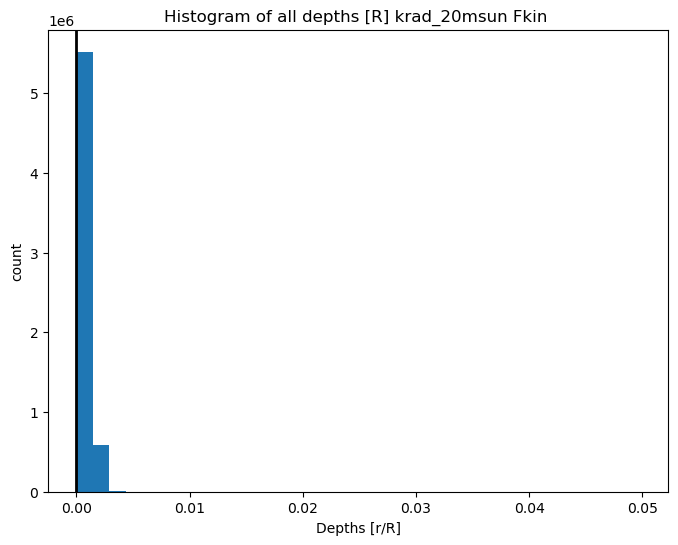

In [22]:
all_data["depth"] = (all_data["r21"] - r_conv) / r_tot
bins = np.arange(0.0, 0.05+dr_grid/r_tot, 3*dr_grid/r_tot)
plt.hist(all_data["depth"], bins=bins);
plt.xlabel('Depths [r/R]');
plt.ylabel('count');
plt.axvline(0.0, color="k", linewidth=2)
plt.title('Histogram of all depths [R] krad_20msun Fkin ')
avg=statistics.mean(all_data["depth"])
print("Mean depth [R]=",avg)

Mean max. depth [R]= 0.0036502127679851155   Mean max. depth [Hp_conv]= 0.05359199965388432


/var/folders/1w/q9ldrd_s7y3gl9ws31_hncd4001bdn/T/ipykernel_7277/3859608896.py:1: FutureWarning: Using the level keyword in DataFrame and Series aggregations is deprecated and will be removed in a future version. Use groupby instead. df.median(level=1) should use df.groupby(level=1).median().
  max_depth = all_data["depth"].max(level="time")


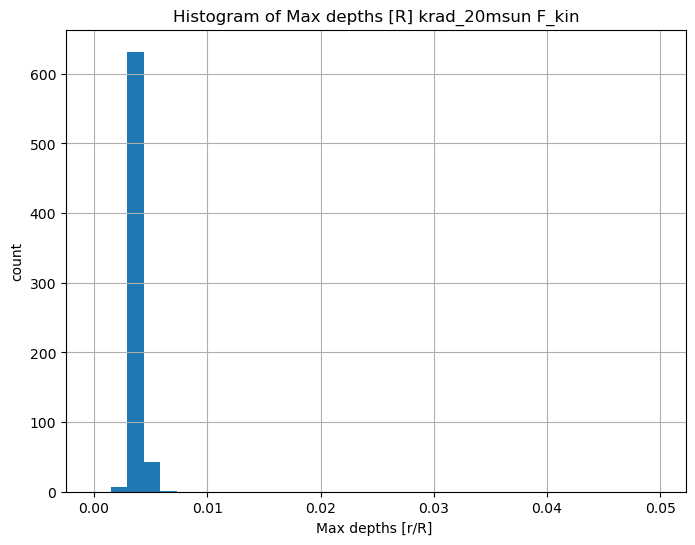

In [23]:
max_depth = all_data["depth"].max(level="time")
max_depth.hist(bins=bins, density=True)
plt.xlabel('Max depths [r/R] ');
plt.ylabel('count');
#plt.xlim(0,0.1)
plt.title('Histogram of Max depths [R] krad_20msun F_kin')
avg=statistics.mean(max_depth)
avghp=statistics.mean(max_depth*r_tot/Hp_conv)
print("Mean max. depth [R]=",avg,"  Mean max. depth [Hp_conv]=",avghp)

Text(0.5, 1.0, 'Max depths versus time krad_20msun F_kin')

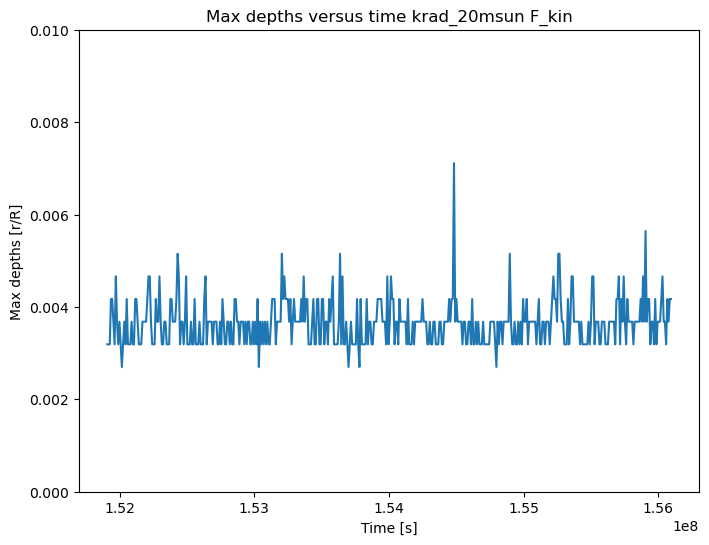

In [24]:
max_depth.plot()
plt.ylim(0,0.01)
plt.xlabel('Time [s]')
plt.ylabel('Max depths [r/R]')
plt.title('Max depths versus time krad_20msun F_kin')

Mean depth [R]= 0.0007674369002394605


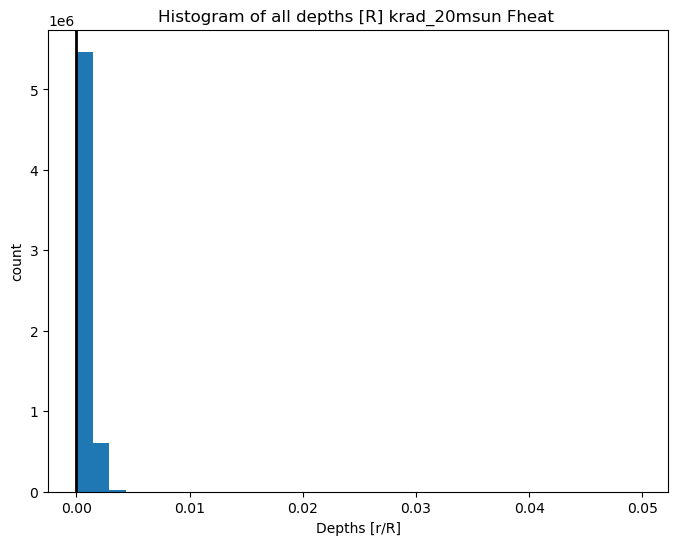

In [25]:
all_data["depth"] = (all_data["r24"] - r_conv) / r_tot
bins = np.arange(0.0, 0.05+dr_grid/r_tot, 3*dr_grid/r_tot)
plt.hist(all_data["depth"], bins=bins);
plt.xlabel('Depths [r/R]');
plt.ylabel('count');
plt.axvline(0.0, color="k", linewidth=2)
plt.title('Histogram of all depths [R] krad_20msun Fheat ')
avg=statistics.mean(all_data["depth"])
print("Mean depth [R]=",avg)

Mean max. depth [R]= 0.004649608437876552   Mean max. depth [Hp_conv]= 0.06826501073550403


/var/folders/1w/q9ldrd_s7y3gl9ws31_hncd4001bdn/T/ipykernel_7277/2083035302.py:1: FutureWarning: Using the level keyword in DataFrame and Series aggregations is deprecated and will be removed in a future version. Use groupby instead. df.median(level=1) should use df.groupby(level=1).median().
  max_depth = all_data["depth"].max(level="time")


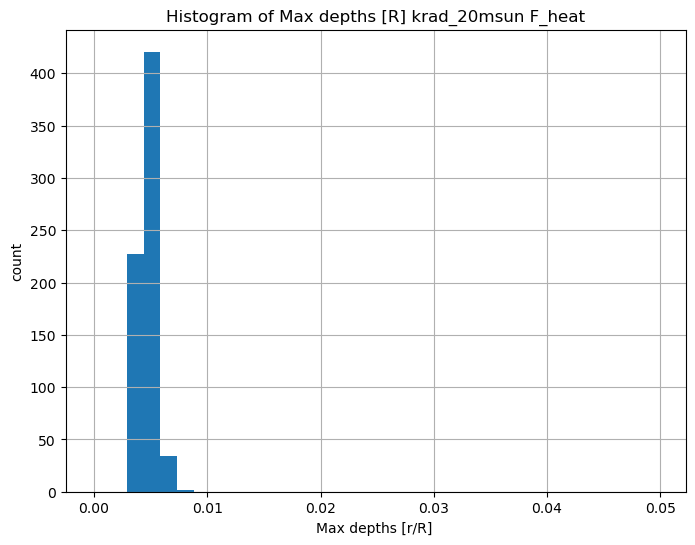

In [26]:
max_depth = all_data["depth"].max(level="time")
max_depth.hist(bins=bins, density=True)
plt.xlabel('Max depths [r/R] ');
plt.ylabel('count');
plt.title('Histogram of Max depths [R] krad_20msun F_heat')
avg=statistics.mean(max_depth)
avghp=statistics.mean(max_depth*r_tot/Hp_conv)
print("Mean max. depth [R]=",avg,"  Mean max. depth [Hp_conv]=",avghp)

Text(0.5, 1.0, 'Max depths versus time krad_20msun F_heat')

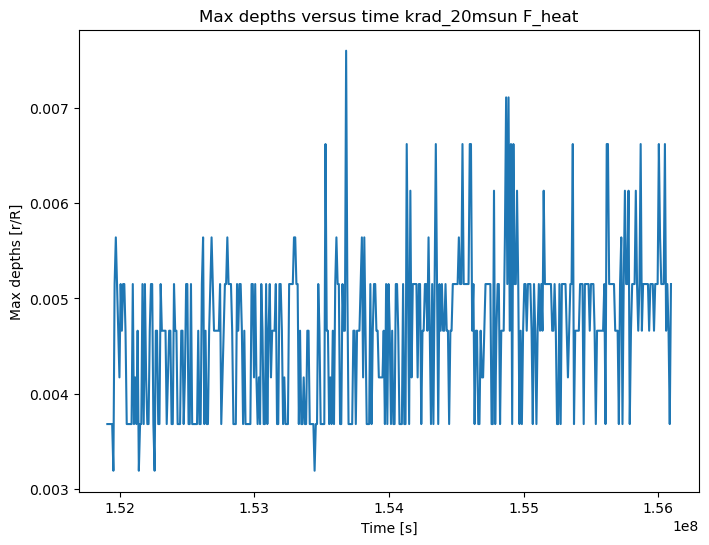

In [27]:
max_depth.plot()
#plt.ylim(0,0.6)
plt.xlabel('Time [s]')
plt.ylabel('Max depths [r/R]')
plt.title('Max depths versus time krad_20msun F_heat')

Mean depth [R]= 0.0007631654768833259


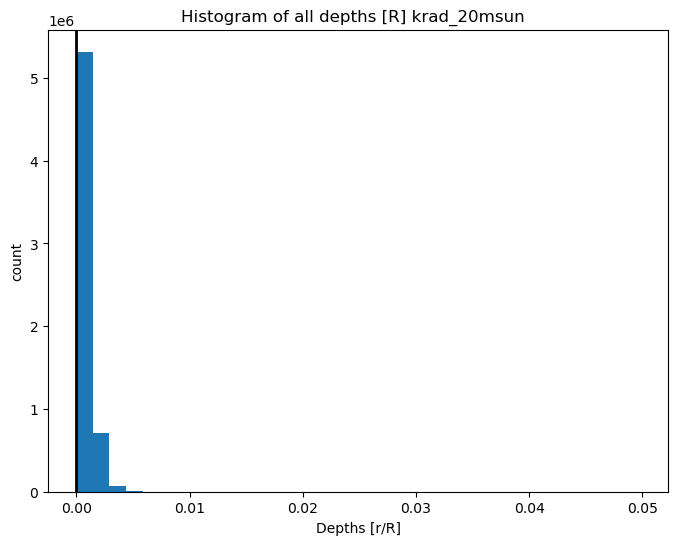

In [28]:
all_data["depth"] = (all_data["r22"] - r_conv) / r_tot
bins = np.arange(0.0, 0.05+dr_grid/r_tot, 3*dr_grid/r_tot)
plt.hist(all_data["depth"], bins=bins);
plt.xlabel('Depths [r/R]');
plt.ylabel('count');
plt.axvline(0.0, color="k", linewidth=2)
plt.title('Histogram of all depths [R] krad_20msun  ')
avg=statistics.mean(all_data["depth"])
print("Mean depth [R]=",avg)

Mean max. depth [R]= 0.006692431728449469   Mean max. depth [Hp_conv]= 0.0982575048831156


/var/folders/1w/q9ldrd_s7y3gl9ws31_hncd4001bdn/T/ipykernel_7277/962295728.py:1: FutureWarning: Using the level keyword in DataFrame and Series aggregations is deprecated and will be removed in a future version. Use groupby instead. df.median(level=1) should use df.groupby(level=1).median().
  max_depth = all_data["depth"].max(level="time")


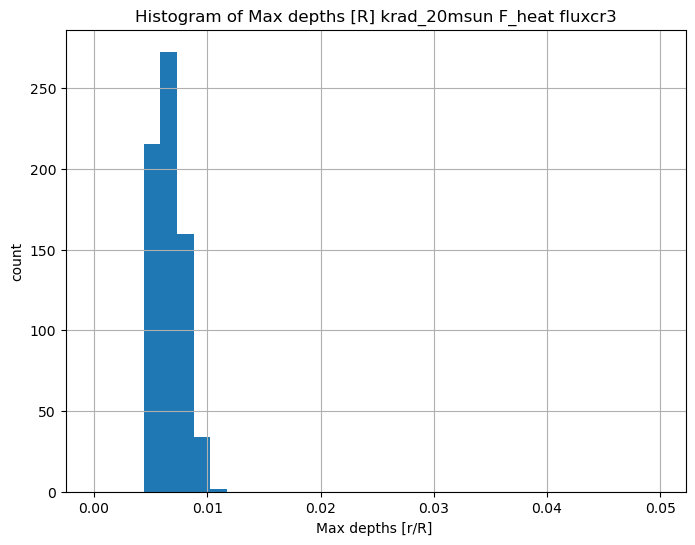

In [14]:
max_depth = all_data["depth"].max(level="time")
max_depth.hist(bins=bins, density=True)
plt.xlabel('Max depths [r/R] ');
plt.ylabel('count');
plt.title('Histogram of Max depths [R] krad_20msun F_heat fluxcr3')
avg=statistics.mean(max_depth)
avghp=statistics.mean(max_depth*r_tot/Hp_conv)
print("Mean max. depth [R]=",avg,"  Mean max. depth [Hp_conv]=",avghp)

Text(0.5, 1.0, 'Max depths versus time krad_20msun fluxcr3')

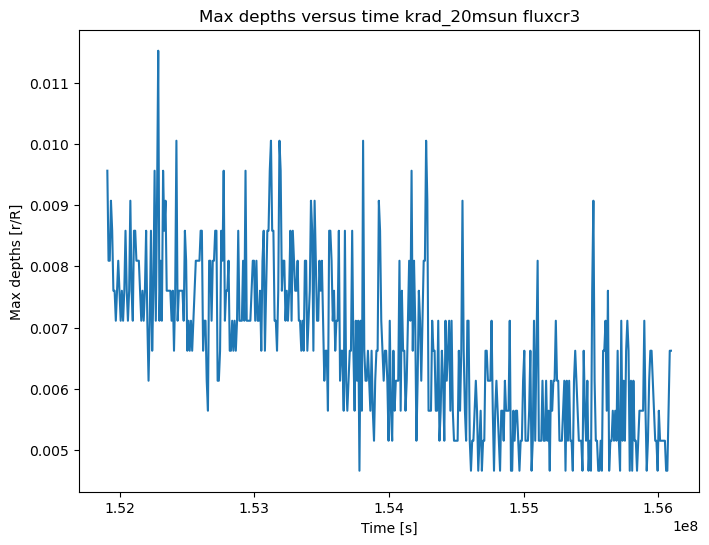

In [15]:
max_depth.plot()
#plt.ylim(0,0.6)
plt.xlabel('Time [s]')
plt.ylabel('Max depths [r/R]')
plt.title('Max depths versus time krad_20msun fluxcr3')